In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/emoti-code-multi-script-emotion-classification-rel/competition_train.csv
/kaggle/input/competitions/emoti-code-multi-script-emotion-classification-rel/sample_submission.csv
/kaggle/input/competitions/emoti-code-multi-script-emotion-classification-rel/competition_test.csv
/kaggle/input/competitions/emoti-code-multi-script-emotion-classification-rel/competition_val.csv


## Import Libraries

In [2]:
!pip install evaluate
!pip install -U bitsandbytes>=0.46.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00


In [3]:
import warnings
from pprint import pprint
import math
import wandb
from kaggle_secrets import UserSecretsClient
import numpy as np
import evaluate
import torch
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import numpy as np

#hf
import datasets
from datasets import load_dataset, load_from_disk, Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForCausalLM
from transformers import DataCollatorWithPadding
from transformers import Gemma3TextForSequenceClassification, GemmaConfig
from transformers import TrainingArguments, Trainer
from transformers import TextClassificationPipeline
from transformers import BitsAndBytesConfig

from peft import LoraConfig, TaskType, LoraModel, get_peft_model, prepare_model_for_kbit_training

In [4]:
import transformers, peft, accelerate
print(transformers.__version__)
print(peft.__version__)
print(accelerate.__version__)

5.0.0
0.18.1
1.12.0


In [5]:
print(torch.cuda.is_available())

True


In [6]:
user_secrets = UserSecretsClient()
HUGGINGFACE_TOKEN = user_secrets.get_secret("HUGGINGFACE_TOKEN")

## Dataset

In [7]:
train_df = pd.read_csv('/kaggle/input/competitions/emoti-code-multi-script-emotion-classification-rel/competition_train.csv')
val_df = pd.read_csv('/kaggle/input/competitions/emoti-code-multi-script-emotion-classification-rel/competition_val.csv')
test_df  = pd.read_csv('/kaggle/input/competitions/emoti-code-multi-script-emotion-classification-rel/competition_test.csv')

In [8]:
train_df

,id,Sentence,language,emotion
0,1801,رُک، بہٕ چھس صرف یہ یقینی بناونٕچ کوٗشش کران ز...,Kashmiri,disgust
1,7895,بہٕ چھس مایوس گژھان ییٚلہ بہٕ بٹوار دۄہ شامس ا...,Kashmiri,anger
2,3369,ꯑꯩꯒꯤ ꯑꯉꯥꯡ ꯌꯣꯛꯄꯗ ꯆꯥꯗꯤꯡꯁꯤ ꯀꯌꯥ ꯌꯥꯝꯅ ꯍꯦꯟꯒꯠꯂꯛꯂꯤꯕꯒꯦ ...,Manipuri,sad
3,5191,بہٕ چھس بیٚنٛکس مٗقابلہٕ جٲتی سودٕکہِ شرح پیش...,Kashmiri,anger
4,7934,کوچ سٕنٛز سپورٹس مینشِپٕچ کٔمی چھےٚ واریاہ مای...,Kashmiri,disgust
...,...,...,...,...
7171,5210,مےٚ ٲس نہٕ پتاہ ییتۍ لوُكھ تٗلن میون ویڈیو وُچ...,Kashmiri,surprise
7172,27,ꯏꯍꯥꯟ ꯍꯥꯟꯅ ꯑꯩꯍꯥꯛꯀꯤ ꯁꯦꯟꯐꯝꯁꯤꯡ ꯑꯁꯤ ꯌꯦꯡꯁꯤꯟꯕꯤꯅꯕ ꯑꯦꯗꯚ...,Manipuri,anger
7173,1432,یہ وٕچھتھ گٔیہ مےٚ خوشی ز تۄہہ نیوٗوٕ پنٛنہ خا...,Kashmiri,happy
7174,5115,اگر بہٕ میچ وٕچھنہٕ نصف رٲژ وۄتھہٕ مےٚ ہیکِہ م...,Kashmiri,fear


In [9]:
val_df

,id,Sentence,language,emotion
0,6349,ᱞᱚᱠᱷᱱᱳ ᱨᱮᱭᱟᱜ ᱯᱟᱵᱞᱤᱠ ᱥᱟᱜᱟᱲᱚᱢ ᱵᱚᱱᱫᱮᱡ ᱨᱮ ᱥᱟᱯᱷᱟᱼᱥᱟ...,Santali,disgust
1,876,مےٚ اوس پننس شر سند اکاونٹ قٲیم کرنس منٛز کینٛ...,Kashmiri,fear
2,6748,ᱤᱧ ᱫᱚ ᱱᱚᱣᱟ ᱥᱟᱛᱟᱢ ᱨᱮ ᱱᱩᱱᱟᱹᱜ ᱜᱮᱧ ᱵᱟᱹᱲᱤᱡ ᱜᱮᱭᱟ ᱡᱮ ...,Santali,fear
3,386,ᱟᱢ ᱫᱚ ᱪᱮᱫ ᱵᱟᱢ ᱵᱟᱰᱟᱭᱟ ᱡᱮ ᱤᱧ ᱓ ᱪᱟᱸᱫᱚ ᱞᱟᱦᱟᱨᱮ ᱠᱟᱹᱣ...,Santali,surprise
4,1025,مےٚ کرییہ خریدارن نیرنہٕ نش رکاونٕچ کوشش مگر ی...,Kashmiri,sad
...,...,...,...,...
2387,87,"ᱪᱷᱤ, ᱩᱱᱤ ᱰᱨᱟᱭᱵᱷᱟᱨ ᱫᱚ ᱛᱩᱨᱩᱭ ᱪᱟᱸᱫᱚ ᱫᱷᱩᱨᱤᱭᱟᱹ ᱟᱡᱟᱜ...",Santali,disgust
2388,6115,ᱫᱳᱠᱟᱱ ᱨᱮᱭᱟᱜ ᱠᱟᱣᱩᱱᱴᱟᱨ ᱨᱮ ᱢᱤᱫ ᱜᱟᱦᱟᱠ ᱮ ᱜᱤᱰᱤ ᱦᱚᱴᱚ ...,Santali,disgust
2389,5690,ہیے سٗدھا، ژے٘ چھٗیہ مستس نوٚو کٹ کرنوومت؟...,Kashmiri,surprise
2390,1848,ꯁꯤꯟꯃꯤꯁꯤꯡ ꯑꯗꯨꯅ ꯃꯣꯗ꯭ꯌꯨꯂꯔ ꯀꯤꯆꯟ ꯄꯥꯟꯈꯠꯅꯕ ꯍꯧꯖꯤꯛ ꯂꯩꯔꯤ...,Manipuri,surprise


In [10]:
test_df

,id,Sentence,language
0,556,ᱵᱤᱨ ᱨᱮ ᱥᱟᱺᱜᱤᱧ ᱠᱷᱚᱱ ᱛᱟᱹᱨᱩᱵ ᱠᱚᱣᱟᱜ ᱵᱚᱛᱚᱨᱟᱱᱟᱜ ᱦᱟᱺᱰ...,Santali
1,1213,ꯀꯁ꯭ꯇꯃꯔ ꯑꯃꯅ ꯑꯩꯈꯣꯏꯒꯤ ꯗꯨꯀꯥꯟꯗ ꯃꯈꯣꯏꯒꯤ ꯄꯣꯠ ꯂꯩꯕꯒꯤ ꯑꯦꯛ...,Manipuri
2,744,ꯑꯌꯨꯛꯇ ꯀꯦꯔꯂꯥꯒꯤ ꯆꯥ ꯒꯤꯂꯥꯁ ꯑꯃꯅ ꯑꯩꯕꯨ ꯅꯨꯡꯉꯥꯏꯕꯅ ꯊꯜꯍꯜꯂꯤ꯫,Manipuri
3,443,ꯔꯦꯁꯇꯣꯔꯦꯟꯠꯒꯤ ꯁꯔꯕꯤꯁ ꯑꯁꯤ ꯉꯁꯤꯗꯤ ꯌꯥꯝꯅ ꯐꯠꯇꯕ ꯑꯣꯏ ꯍꯥꯏꯅ...,Manipuri
4,7673,ᱵᱟᱦᱟ ᱴᱚᱵ ᱵᱮᱲᱦᱟᱭᱛᱮ ᱛᱤᱡᱩ ᱠᱚ ᱴᱩᱸᱰᱟᱝ ᱵᱟᱲᱟᱭ ᱧᱮᱞ ᱱᱚᱣ...,Santali
...,...,...,...
2387,1275,ᱤᱧ ᱟᱢ ᱟᱭᱳᱣᱟᱜ ᱥᱟᱶᱟᱨ ᱮᱴᱠᱮᱴᱚᱲᱮ ᱠᱟᱛᱷᱟ ᱵᱟᱰᱟᱭ ᱠᱟᱛᱮ ᱟ...,Santali
2388,7949,ꯑꯩꯈꯣꯏꯒꯤ ꯐ꯭ꯔꯟꯇꯂꯥꯏꯟ ꯍꯣꯡꯈ꯭ꯔꯕ ꯃꯇꯨꯡꯗ ꯀꯁꯇꯃꯔꯁꯤꯡꯒꯤ ꯄꯦꯟ...,Manipuri
2389,9528,سون شاشوت چھٗ اکھ ذہین طالب علم۔ تمہِ کوٚر آ...,Kashmiri
2390,9203,ꯍꯧꯖꯤꯛꯀꯥꯟꯗꯤ ꯑꯔꯇꯤꯐꯤꯁ꯭ꯌꯦꯜ ꯄꯤꯠꯆ ꯑꯃꯗ ꯑꯌꯨꯛꯀꯤ ꯐꯠꯁꯥꯜꯒꯤ...,Manipuri


In [11]:
# Encode emotion labels to integers
label_encoder = LabelEncoder()
train_df["label"] = label_encoder.fit_transform(train_df["emotion"])
val_df["label"] = label_encoder.transform(val_df["emotion"])

In [12]:
ds = DatasetDict({
    "train": Dataset.from_pandas(train_df[["Sentence", "label"]].reset_index(drop=True)),
    "validation": Dataset.from_pandas(val_df[["Sentence", "label"]].reset_index(drop=True)),
    "test": Dataset.from_pandas(test_df[["id","Sentence"]].reset_index(drop=True)),
})

In [13]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['Sentence', 'label'],
        num_rows: 7176
    })
    validation: Dataset({
        features: ['Sentence', 'label'],
        num_rows: 2392
    })
    test: Dataset({
        features: ['id', 'Sentence'],
        num_rows: 2392
    })
})


In [14]:
ds["train"][0]

{'Sentence': 'رُک، بہٕ چھس صرف یہ یقینی بناونٕچ کوٗشش کران ز مےٚ چھ فراہم کرنہٕ آمتیٚن خدماتن خٲطرٕ معقول قۭمت میلان۔',
 'label': 1}

In [15]:
ds["validation"][0]

{'Sentence': 'ᱞᱚᱠᱷᱱᱳ ᱨᱮᱭᱟᱜ ᱯᱟᱵᱞᱤᱠ ᱥᱟᱜᱟᱲᱚᱢ ᱵᱚᱱᱫᱮᱡ ᱨᱮ ᱥᱟᱯᱷᱟᱼᱥᱟᱹᱯᱷᱤ ᱨᱮᱭᱟᱜ ᱟᱱᱟᱴ ᱫᱚ ᱟᱹᱲᱤᱥ ᱜᱮᱭᱟ ᱾',
 'label': 1}

In [16]:
ds["test"][0]

{'id': 556,
 'Sentence': 'ᱵᱤᱨ ᱨᱮ ᱥᱟᱺᱜᱤᱧ ᱠᱷᱚᱱ ᱛᱟᱹᱨᱩᱵ ᱠᱚᱣᱟᱜ ᱵᱚᱛᱚᱨᱟᱱᱟᱜ ᱦᱟᱺᱰᱨᱟᱹᱣ ᱤᱧᱟᱹᱜ ᱡᱟᱝ ᱠᱚᱨᱮ ᱥᱤᱨᱥᱤᱨᱟᱹᱣᱮ ᱡᱟᱱᱟᱢᱮᱫ ᱛᱟᱦᱮᱸᱜ ᱾'}

In [17]:
ds["train"].features['label']

Value('int64')

In [18]:
id2label = {i: label for i, label in enumerate(label_encoder.classes_)}
label2id = {label: i for i, label in id2label.items()}

## Tokenizer


A **tokenizer** converts raw text into a numerical format that a model can understand. It splits text into smaller units called tokens (words, subwords, or characters) and maps them to unique IDs using a vocabulary. It also adds special tokens (like `[CLS]`, `[SEP]`, or EOS), handles padding and truncation, and generates attention masks. This process ensures consistent input length and structure for the model. In short, the tokenizer acts as a bridge between human language and machine-readable input, enabling models to process, learn from, and generate text effectively.


In [19]:
model_id = "google/gemma-3-1b-it"
tokenizer = AutoTokenizer.from_pretrained(
    model_id, token=HUGGINGFACE_TOKEN
)

config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

In [20]:
def tokenize(example):
    return tokenizer(
        example['Sentence'],
        padding=False,
        truncation=True,
        max_length=256
    )

In [21]:
tokenized_ds = ds.map(tokenize, batched=True, num_proc=4, remove_columns=['Sentence'])
print(tokenized_ds)

Map (num_proc=4):   0%|          | 0/7176 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/2392 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/2392 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 7176
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 2392
    })
    test: Dataset({
        features: ['id', 'input_ids', 'attention_mask'],
        num_rows: 2392
    })
})


In [22]:
tokenized_ds["train"][0]

{'label': 1,
 'input_ids': [2,
  236871,
  237880,
  236927,
  237108,
  21248,
  251588,
  40331,
  236914,
  47087,
  11084,
  174286,
  31051,
  2511,
  251588,
  237343,
  5414,
  248916,
  68976,
  4246,
  1436,
  5306,
  995,
  236980,
  455,
  392,
  40331,
  108721,
  4246,
  97207,
  251588,
  37596,
  8458,
  455,
  392,
  236872,
  90912,
  236872,
  3268,
  455,
  416,
  53661,
  251588,
  5951,
  22563,
  3417,
  457,
  411,
  21497,
  6142,
  57248,
  237407],
 'attention_mask': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1]}

## Data Collator


A **data collator** in Hugging Face prepares batches of data before feeding them into the model. Its main job is to **combine individual samples into a batch and handle padding dynamically** so all sequences in the batch have the same length. This avoids unnecessary padding across the entire dataset and improves efficiency. It can also apply additional processing like creating attention masks or labels. For example, `DataCollatorWithPadding` pads each batch to the longest sequence in that batch. In short, it ensures your data is **properly formatted, padded, and ready for efficient training**.


In [23]:
data_collator = DataCollatorWithPadding(tokenizer,padding=True)

## Finetune with LoRA


In [24]:
#lora
lora_config = LoraConfig(
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,
    lora_alpha=32,
    lora_dropout=0.1,
    bias="none",
)

In [25]:
model = Gemma3TextForSequenceClassification.from_pretrained(
    model_id,
    num_labels=6,
    id2label=id2label,
    label2id=label2id,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    token=HUGGINGFACE_TOKEN,
)

model.safetensors:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

Gemma3TextForSequenceClassification LOAD REPORT from: google/gemma-3-1b-it
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [26]:
lora_model = get_peft_model(model, lora_config)
lora_model.print_trainable_parameters()
print(lora_model)

trainable params: 2,988,800 || all params: 1,002,881,664 || trainable%: 0.2980
PeftModelForSequenceClassification(
  (base_model): LoraModel(
    (model): Gemma3TextForSequenceClassification(
      (model): Gemma3TextModel(
        (embed_tokens): Gemma3TextScaledWordEmbedding(262144, 1152, padding_idx=0)
        (layers): ModuleList(
          (0-25): 26 x Gemma3DecoderLayer(
            (self_attn): Gemma3Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=1152, out_features=1024, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=1152, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=1024, bias=False)
                )
                (lora_embedding_A): ParameterDict()
    

![Screenshot 2026-04-30 140003.png](<attachment:Screenshot 2026-04-30 140003.png>)
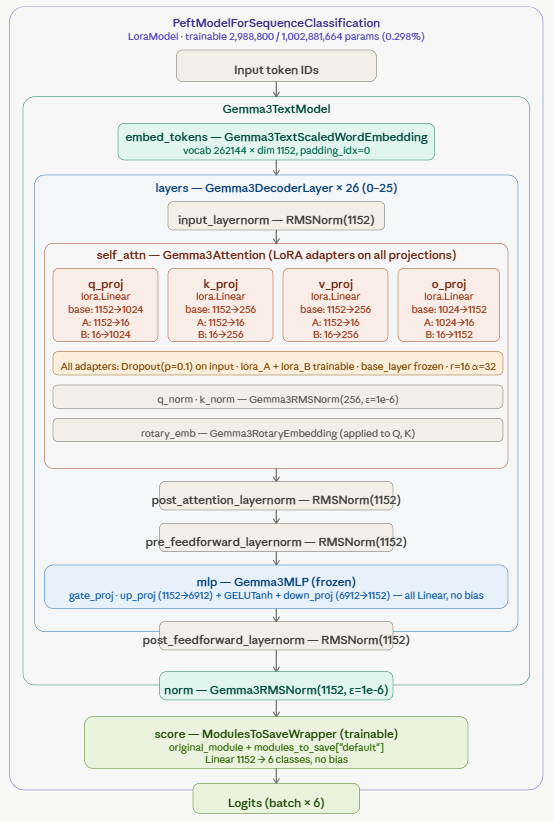

Macro End to End Data Flow


![Screenshot 2026-04-30 140326.png](<attachment:Screenshot 2026-04-30 140326.png>)
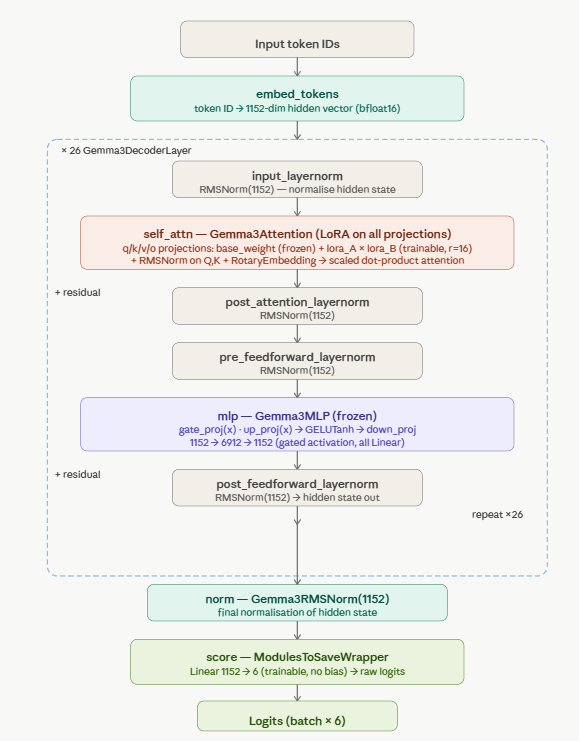

A single LoRA projection (e.g. `q_proj`) during a forward pass.

![Screenshot 2026-04-30 140435.png](<attachment:Screenshot 2026-04-30 140435.png>)
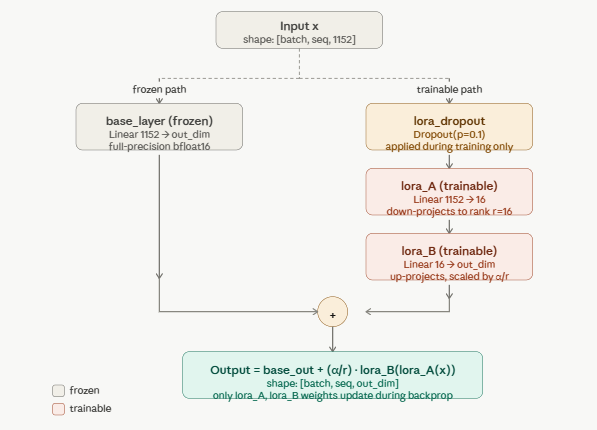

The top diagram shows the macro flow — tokens enter as IDs, get embedded into 1152-dim vectors, then pass through 26 identical decoder layers. Each layer runs four operations in sequence: normalise → attend (with LoRA) → normalise → feed-forward (frozen MLP) → normalise. After all 26 layers, a final RMSNorm feeds the `score` head which collapses 1152 dims down to 6 class logits.

The bottom diagram zooms into what makes this LoRA rather than full fine-tuning. Every projection (`q`, `k`, `v`, `o`) splits the input `x` down two parallel paths simultaneously. The frozen `base_layer` computes the full-rank output it learned during pre-training. The trainable path runs `x` through `Dropout → lora_A (1152→16) → lora_B (16→out_dim)` — a tiny low-rank detour. The two outputs are added together, scaled by `α/r = 32/16 = 2`. During backpropagation, only `lora_A` and `lora_B` receive gradients; the base layer is never touched. This is why only 0.298% of parameters are trainable despite the model being 1B parameters.

In [27]:
# Configuration and architecture details
configuration = lora_model.config
print(configuration)

Gemma3TextConfig {
  "_sliding_window_pattern": 6,
  "architectures": [
    "Gemma3ForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "attn_logit_softcapping": null,
  "bos_token_id": 2,
  "cache_implementation": "hybrid",
  "dtype": "bfloat16",
  "eos_token_id": [
    1,
    106
  ],
  "final_logit_softcapping": null,
  "head_dim": 256,
  "hidden_activation": "gelu_pytorch_tanh",
  "hidden_size": 1152,
  "id2label": {
    "0": "anger",
    "1": "disgust",
    "2": "fear",
    "3": "happy",
    "4": "sad",
    "5": "surprise"
  },
  "initializer_range": 0.02,
  "intermediate_size": 6912,
  "label2id": {
    "anger": 0,
    "disgust": 1,
    "fear": 2,
    "happy": 3,
    "sad": 4,
    "surprise": 5
  },
  "layer_types": [
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention

In [28]:
print(lora_model.get_memory_footprint()/1e9)

2.011729154


In [29]:
# Evaluation metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1  = f1_metric.compute(predictions=predictions, references=labels, average="macro")
    return {**acc, **f1}

In [30]:
training_args = TrainingArguments(
    output_dir='gemma3_emotion_ft',
    eval_strategy="epoch",
    num_train_epochs=15,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    bf16=True,
    fp16=False,
    tf32=False,
    gradient_accumulation_steps=2,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.05,
    lr_scheduler_type="cosine",
    logging_dir='logs',
    logging_steps=100,
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to='none',
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [31]:
trainer = Trainer(model=model, args = training_args, train_dataset=tokenized_ds["train"], eval_dataset=tokenized_ds["validation"], compute_metrics=compute_metrics, data_collator = data_collator)

In [32]:
results = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,3.564912,1.769535,0.247492,0.199283
2,3.263569,1.663575,0.321488,0.298409
3,2.956515,1.593343,0.370819,0.347162
4,2.377929,1.617621,0.398411,0.377611
5,2.051523,1.880463,0.396739,0.380148
6,1.653589,2.135872,0.398829,0.384934
7,1.069236,2.762266,0.399666,0.376430
8,0.882542,3.049426,0.393813,0.383905
9,0.539229,3.254189,0.396321,0.386200
10,0.359921,3.460787,0.409699,0.391769


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### Inference

In [33]:
model.config.id2label = id2label
model.config.label2id = label2id

In [34]:
classifier = TextClassificationPipeline(model=model, tokenizer=tokenizer, framework='pt', task="sentiment-analysis")

In [35]:
# Santali (Ol Chiki)
print(classifier("ᱱᱚᱶᱟ ᱫᱚ ᱦᱩᱭᱩᱜ ᱠᱟᱱᱟ ᱤᱧᱤᱡ ᱢᱤᱥᱨᱟᱧᱼᱟᱜ ᱡᱟᱱᱟᱢ ᱢᱟᱦᱟ ᱞᱟᱹᱜᱤᱫ ᱾ ᱟᱞᱮ ᱫᱚ ᱩᱱᱤ ᱢᱤᱫᱴᱟᱝ ᱥᱟᱨᱯᱨᱟᱭᱤᱡᱽ ᱯᱟᱨᱴᱤ ᱞᱮ ᱮᱢᱟᱭ ᱠᱟᱱᱟ ᱾")) #Actual label: Happy

[{'label': 'happy', 'score': 0.9998981952667236}]


In [36]:
# Kashmiri (Arabic script)
print(classifier("کوچ سٕنٛز سپورٹس مینشِپٕچ کٔمی چھےٚ واریاہ مایوس کن۔")) #Actual label: Disgust

[{'label': 'disgust', 'score': 0.997616171836853}]


In [37]:
# Manipuri (Meitei Mayek)
print(classifier("ꯍꯦꯜꯊ ꯁꯦꯟꯇꯔꯅ ꯄꯤꯔꯤꯕ ꯍꯤꯗꯥꯛꯁꯤꯡ ꯑꯁꯤ ꯃꯇꯝ ꯂꯣꯏꯔꯕꯒꯨꯝ ꯇꯧꯋꯤ ꯑꯃꯁꯨꯡ ꯃꯁꯤ ꯀꯤꯅꯤꯡꯉꯥꯏ ꯑꯣꯏ꯫")) # Actual label: Fear

[{'label': 'fear', 'score': 0.99142986536026}]


In [38]:
model.eval()

Gemma3TextForSequenceClassification(
  (model): Gemma3TextModel(
    (embed_tokens): Gemma3TextScaledWordEmbedding(262144, 1152, padding_idx=0)
    (layers): ModuleList(
      (0-25): 26 x Gemma3DecoderLayer(
        (self_attn): Gemma3Attention(
          (q_proj): lora.Linear(
            (base_layer): Linear(in_features=1152, out_features=1024, bias=False)
            (lora_dropout): ModuleDict(
              (default): Dropout(p=0.1, inplace=False)
            )
            (lora_A): ModuleDict(
              (default): Linear(in_features=1152, out_features=16, bias=False)
            )
            (lora_B): ModuleDict(
              (default): Linear(in_features=16, out_features=1024, bias=False)
            )
            (lora_embedding_A): ParameterDict()
            (lora_embedding_B): ParameterDict()
            (lora_magnitude_vector): ModuleDict()
          )
          (k_proj): lora.Linear(
            (base_layer): Linear(in_features=1152, out_features=256, bias=False)
   

In [39]:
tokenized_ds['test']

Dataset({
    features: ['id', 'input_ids', 'attention_mask'],
    num_rows: 2392
})

In [40]:
# Predict
predictions = trainer.predict(tokenized_ds['test']).predictions.argmax(axis=1)

In [41]:
# Prepare Submission File
submission_df = pd.DataFrame({
    "id": tokenized_ds['test']['id'],
    "emotion": [id2label[p] for p in predictions]
})
submission_df.to_csv("submission.csv", index=False)

Result based on `submission.csv`

Top one is based on 15 epochs and bottom one is based on 5 epochs

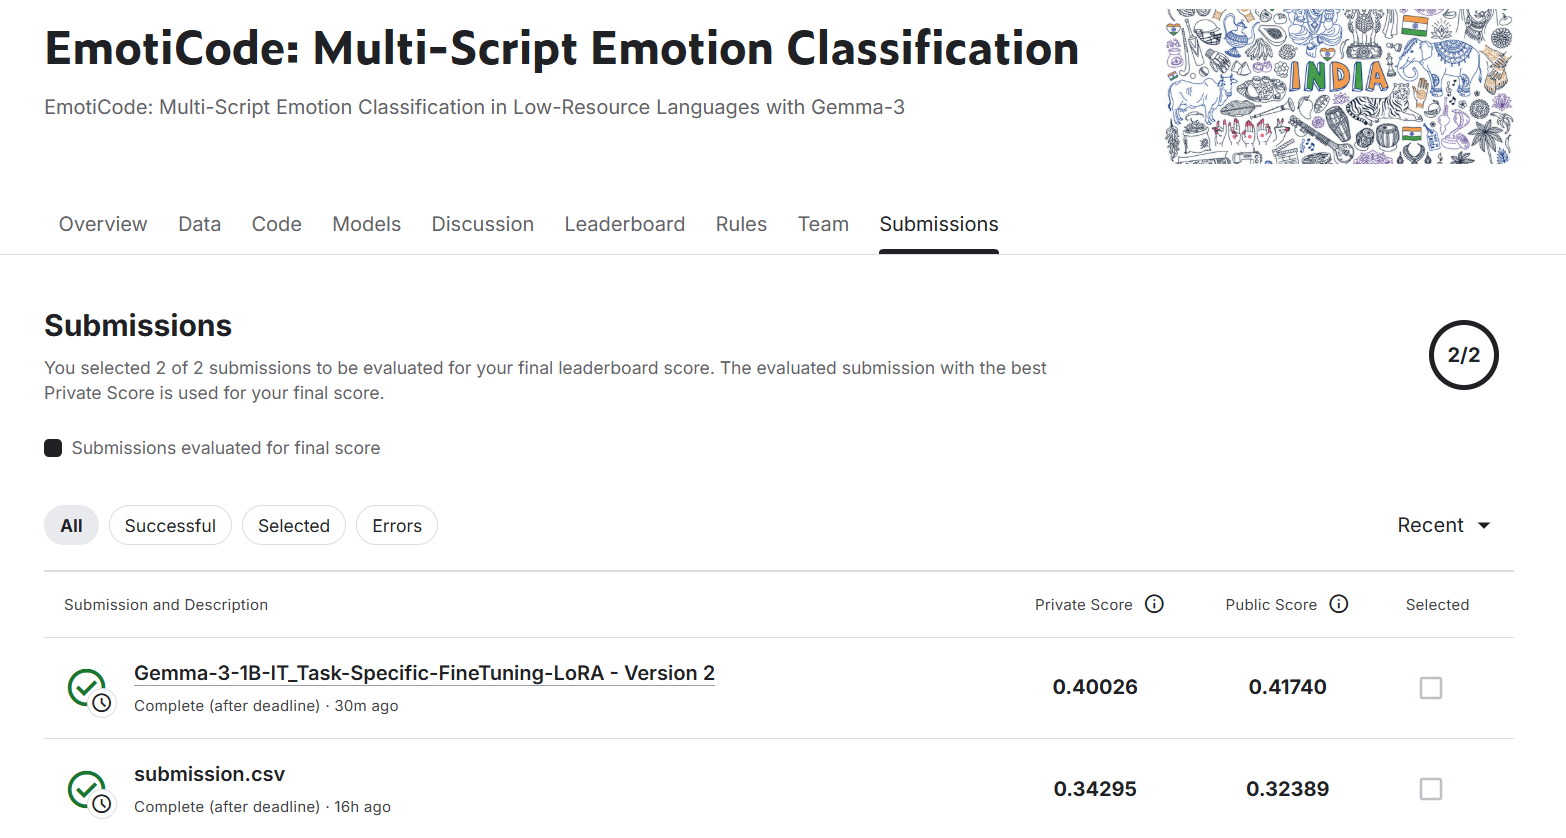